# UNet Training v17

## What changed from v16

| # | Area | Change |
|---|------|--------|
| 1 | **Model — Dropout** | `ConvBlock` now accepts a `dropout` argument and applies `nn.Dropout2d` (spatial dropout) after each block. Rates: enc1=0.1, enc2=0.1, enc3=0.2, enc4=0.2, bottleneck=0.3, decoder blocks=0.1. Zero dropout in v15/v16 was the primary cause of the train/val Dice gap. |
| 2 | **Augmentation — strength** | Added `ElasticTransform` (anatomical shape variation), `GridDistortion`, `CoarseDropout` / `CoarseDropout`-fallback (forces spatial generalisation), wider rotation ±25°, and stronger brightness/contrast ±0.15. The previous pipeline was too mild for CT. |
| 3 | **Metrics — lung-only split** | `compute_metrics` and `run_epoch` now also return `dice_lung` — Dice computed only on slices that contain lung tissue. This separates the inflated signal from trivial empty-slice predictions and gives an honest view of true generalisation. |
| 4 | **Metrics — empty-slice inflation** | Empty slices produce near-perfect Dice by convention (both pred and GT are all-zero), masking the true train/val gap. Logging `dice_lung` exposes this. |
| 5 | **Optimizer — weight decay** | AdamW `weight_decay` confirmed at `1e-4` (was implicit/default in v16 preflight). |
| 6 | **Scheduler** | Kept v16's CosineAnnealingWarmRestarts + linear warmup — confirmed not the bottleneck. |

## Overview
Trains a 2-D UNet for lung segmentation on CT scan slices.

## Cell Guide

| Cell | Purpose |
|------|---------|
| **1 — Environment** | GPU check |
| **2 — Setup** | Paths, thread helper, slice_index download |
| **3 — Imports** | Packages |
| **4 — Hyperparameters** | LR, batch size, scheduler config, dropout rates |
| **5 — Model** | UNetV3 — same U-Net with spatial dropout added |
| **6 — Helpers** | Loss, metrics (+ lung-only dice), dataset, dataloaders, checkpoint/log |
| **7 — Pre-flight** | HDF5 download, dataloaders, model init, checkpoint load |
| **8 — Training** | Training loop with lung-only dice reported each epoch |
| **9 — Evaluation** | Test-set eval |
| **10 — Visualisation** | Prediction samples |

**Run order:** 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → *(9 and 10 optional)*

In [ ]:
# ============================================================
# CELL 1 — Environment check
# ============================================================
import torch, platform, shutil

print("=" * 55)
print("ENVIRONMENT")
print("=" * 55)
print(f"Python  : {platform.python_version()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {props.total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError(
        "No GPU detected.\n"
        "Go to Runtime > Change runtime type > T4 GPU, then re-run."
    )
disk = shutil.disk_usage("/")
print(f"Disk    : {disk.free / 1e9:.1f} GB free")
print("=" * 55)
print("[Cell 1 OK]")

ENVIRONMENT
Python  : 3.12.13
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
Disk    : 68.8 GB free
[Cell 1 OK]


In [ ]:
# ============================================================
# CELL 2 — Paths, helpers, index download
# Unchanged from v16.
# ============================================================
import os, json, time, torch, threading, shutil
from huggingface_hub import hf_hub_download, HfApi

def run_with_dots(fn, label, dot_interval=1.0, timeout=180, heartbeat=30):
    result = [None]; error = [None]; done = threading.Event()
    def worker():
        try:    result[0] = fn()
        except Exception as e: error[0] = e
        finally: done.set()
    t = threading.Thread(target=worker, daemon=True)
    print(label, end="", flush=True)
    t.start()
    elapsed = 0.0; last_beat = 0.0
    while not done.wait(dot_interval):
        elapsed += dot_interval
        if elapsed >= timeout:
            error[0] = TimeoutError("Timed out after " + str(timeout) + "s")
            done.set(); break
        if elapsed - last_beat >= heartbeat:
            print(f"\n  [{time.strftime('%H:%M:%S')}] still waiting... ({int(elapsed)}s)",
                  flush=True)
            last_beat = elapsed
        else:
            print(".", end="", flush=True)
    t.join(timeout=2)
    if error[0] is not None: raise error[0]
    return result[0]

LOCAL_META     = "/content/slice_index.json"
CHECKPOINT_DIR = "/content"
HF_REPO        = "hourouu/data"
MODEL2_REPO    = "hourouu/model4"
H5_LOCAL       = "/content/slices.h5"

print("HF repo        : " + HF_REPO)
print("Model repo    : " + MODEL2_REPO)
print("HDF5 local     : " + H5_LOCAL)
print("Checkpoint dir : " + CHECKPOINT_DIR)

if os.path.exists(LOCAL_META):
    print("slice_index.json already local — skipping.", flush=True)
else:
    run_with_dots(
        lambda: hf_hub_download(
            repo_id=HF_REPO, filename="slice_index.json",
            repo_type="dataset", local_dir="/content"),
        "Downloading slice_index.json from HF", timeout=120)
    print(" done (" + str(round(os.path.getsize(LOCAL_META)/1e6, 1)) + " MB).",
          flush=True)

with open(LOCAL_META) as f:
    _idx = json.load(f)
_nl = sum(1 for s in _idx["slices"] if s["kind"] == "lung")
_ne = sum(1 for s in _idx["slices"] if s["kind"] == "empty")
print("Index: " + str(len(_idx["slices"])) + " slices (" +
      str(_nl) + " lung + " + str(_ne) + " empty)")
print("[Cell 2 OK]")

HF repo        : hourouu/data
Model repo    : hourouu/model4
HDF5 local     : /content/slices.h5
Checkpoint dir : /content
slice_index.json already local — skipping.
Index: 106820 slices (97244 lung + 9576 empty)
[Cell 2 OK]


In [ ]:
# ============================================================
# CELL 3 — Imports
# ============================================================
import subprocess, sys
for pkg in ["albumentations", "h5py"]:
    try: __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import os, json, time, random, threading
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import h5py
from torch.utils.data import DataLoader, Dataset

try:
    import albumentations as A
    ALBUMENTATIONS_AVAILABLE = True
    print("albumentations : OK")
except ImportError:
    ALBUMENTATIONS_AVAILABLE = False
    print("WARNING: albumentations not available — augmentation disabled")

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print("[Cell 3 OK]")

albumentations : OK
PyTorch 2.10.0+cu128 | CUDA: True
[Cell 3 OK]


In [ ]:
# ============================================================
# CELL 4 — Hyperparameters
# v17 changes:
#   - DROPOUT_* rates added (were 0 in v15/v16 — primary fix)
#   - N_EPOCHS bumped to 70 to give the stronger augmentation
#     more time to converge (augmented data is harder to fit)
#   - PATIENCE stays 25 — enough to survive a cosine cycle
# ============================================================
assert "HF_REPO" in globals(), "Run Cell 2 first."

SPLIT_SEED    = 42
VAL_FRACTION  = 0.10
TEST_FRACTION = 0.10
BATCH_SIZE    = 8
LR            = 1e-4
N_EPOCHS      = 70
PATIENCE      = 20
PRINT_EVERY   = 100

# ── Dropout rates per stage (v17 addition) ────────────────────
# Spatial dropout (Dropout2d) zeros entire feature maps, which is
# stronger and more appropriate than scalar dropout for conv nets.
# Rates increase with depth: shallow layers learn simple edges and
# should be disturbed less; the bottleneck holds the most abstract
# (and most overfit-prone) representations.
DROPOUT_ENC_SHALLOW = 0.10   # enc1, enc2
DROPOUT_ENC_DEEP    = 0.20   # enc3, enc4
DROPOUT_BOTTLENECK  = 0.30   # bottleneck
DROPOUT_DEC         = 0.10   # all decoder blocks

# ── Scheduler ────────────────────────────────────────────────
WARMUP_EPOCHS = 5
T_0           = 10
T_MULT        = 2
ETA_MIN       = 1e-6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration:")
print(f"  Split seed          : {SPLIT_SEED}")
print(f"  Val fraction        : {VAL_FRACTION}")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  LR                  : {LR}")
print(f"  Epochs              : {N_EPOCHS}")
print(f"  Patience            : {PATIENCE}")
print(f"  Device              : {DEVICE}")
print(f"  Warmup epochs       : {WARMUP_EPOCHS}")
print(f"  Cosine T_0          : {T_0}  T_mult={T_MULT}  eta_min={ETA_MIN}")
print(f"  Dropout enc shallow : {DROPOUT_ENC_SHALLOW}")
print(f"  Dropout enc deep    : {DROPOUT_ENC_DEEP}")
print(f"  Dropout bottleneck  : {DROPOUT_BOTTLENECK}")
print(f"  Dropout decoder     : {DROPOUT_DEC}")
print("[Cell 4 OK]")

Configuration:
  Split seed          : 42
  Val fraction        : 0.1
  Batch size          : 8
  LR                  : 0.0001
  Epochs              : 70
  Patience            : 20
  Device              : cuda
  Warmup epochs       : 5
  Cosine T_0          : 10  T_mult=2  eta_min=1e-06
  Dropout enc shallow : 0.1
  Dropout enc deep    : 0.2
  Dropout bottleneck  : 0.3
  Dropout decoder     : 0.1
[Cell 4 OK]


In [ ]:
# ============================================================
# CELL 5 — Model definition
# UNetV3: identical topology to UNetV2 but with spatial dropout
# (nn.Dropout2d) added to every conv block.
#
# WHY Dropout2d and not Dropout:
#   In conv feature maps adjacent pixels are highly correlated.
#   Scalar dropout zeroing individual pixels is barely disruptive
#   because neighbours retain the same information. Dropout2d zeros
#   entire channels, forcing the network to not rely on any single
#   feature map — a much stronger regulariser for conv nets.
#   (Tompson et al., 2015 — "Efficient Object Localization Using
#   Convolutional Networks", CVPR)
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout2d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetV3(nn.Module):
    """UNetV2 + spatial dropout at every stage."""
    def __init__(self, in_ch=1, base_ch=32,
                 drop_enc_shallow=0.10,
                 drop_enc_deep=0.20,
                 drop_bottleneck=0.30,
                 drop_dec=0.10):
        super().__init__()
        b = base_ch
        # Encoder — dropout increases with depth
        self.enc1 = ConvBlock(in_ch, b,    dropout=drop_enc_shallow)
        self.enc2 = ConvBlock(b,   b*2,   dropout=drop_enc_shallow)
        self.enc3 = ConvBlock(b*2, b*4,   dropout=drop_enc_deep)
        self.enc4 = ConvBlock(b*4, b*8,   dropout=drop_enc_deep)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck — highest dropout (most abstract, most overfit-prone)
        self.bottleneck = ConvBlock(b*8, b*16, dropout=drop_bottleneck)
        # Decoder
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8,  dropout=drop_dec)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4,  dropout=drop_dec)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2,  dropout=drop_dec)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b,    dropout=drop_dec)
        # Output
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        return self.out(d1)


_m = UNetV3()
print(f"UNetV3 | Parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m
print("[Cell 5 OK]")

UNetV3 | Parameters: 7,762,465
[Cell 5 OK]


In [ ]:
# ============================================================
# CELL 6 — Helpers
# v17 changes:
#   [A] Augmentation pipeline strengthened
#   [B] compute_metrics returns dice_lung (lung-only Dice)
#   [C] Dataset passes hdf5 kind to enable lung-only metric
#   [D] build_dataloaders stores kind list in dataset for
#       lung-only tracking in run_epoch
# ============================================================
assert "DEVICE"   in globals(), "Run Cell 4 first."
assert "H5_LOCAL" in globals(), "Run Cell 2 first."


# ── Loss ─────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1); t = targets.view(-1)
        return 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)

class CombinedLoss(nn.Module):
    """50% BCE + 50% Dice."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(); self.dice = DiceLoss()
        self.bw, self.dw = bce_weight, dice_weight
    def forward(self, logits, targets):
        return self.bw*self.bce(logits, targets) + self.dw*self.dice(logits, targets)


# ── Metrics ──────────────────────────────────────────────────
# [B] Returns both overall dice and dice_lung.
# dice_lung is computed only on slices where the GT mask has any
# positive pixels. This strips out the trivial empty-slice
# predictions that inflate overall Dice and hide the true gap.
@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > threshold).float()
    t     = targets.float()
    tp = (preds * t).sum(dim=(1,2,3))
    fp = (preds * (1-t)).sum(dim=(1,2,3))
    fn = ((1-preds) * t).sum(dim=(1,2,3))
    tn = ((1-preds) * (1-t)).sum(dim=(1,2,3))

    dice_per = (2*tp + eps) / (2*tp + fp + fn + eps)   # shape (B,)
    iou_per  = (tp + eps) / (tp + fp + fn + eps)
    sens_per = (tp + eps) / (tp + fn + eps)
    spec_per = (tn + eps) / (tn + fp + eps)

    # Lung-only: keep only samples where GT has any positive pixel
    has_lung = t.sum(dim=(1,2,3)) > 0   # (B,) bool
    if has_lung.any():
        dice_lung = dice_per[has_lung].mean().item()
    else:
        dice_lung = float("nan")  # batch has no lung slices — rare

    return {
        "dice":        dice_per.mean().item(),
        "dice_lung":   dice_lung,          # <-- key new metric
        "iou":         iou_per.mean().item(),
        "sensitivity": sens_per.mean().item(),
        "specificity": spec_per.mean().item(),
    }


# ── Dataset ──────────────────────────────────────────────────
# [C] Stores the HDF5 kind string per index so run_epoch can
# identify lung slices without an extra HDF5 lookup.
class CachedSliceDataset(Dataset):
    def __init__(self, indices, kinds, augment=False):
        """
        indices : list of integer HDF5 row indices
        kinds   : list of strings ('lung' / 'empty') parallel to indices
        augment : whether to apply training augmentation
        """
        self.indices = indices
        self.kinds   = kinds      # parallel list — same length as indices
        self.augment = augment and ALBUMENTATIONS_AVAILABLE
        if self.augment:
            # [A] Strengthened augmentation pipeline for CT lung segmentation.
            #
            # Key additions over v16:
            #   ElasticTransform — simulates anatomical shape variation between
            #     patients; standard in medical image segmentation literature.
            #   GridDistortion   — complementary spatial deformation.
            #   CoarseDropout    — randomly blacks out rectangular patches,
            #     forcing the model not to memorise local texture patterns.
            #     Falls back to Cutout on older albumentations versions.
            #   Wider rotation ±25° (was ±15°) — lungs are largely
            #     rotation-invariant; more variation reduces memorisation.
            #   Stronger brightness/contrast ±0.15 (was ±0.10) — CT Hounsfield
            #     ranges vary considerably across scanners and protocols.
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.2),
                A.Rotate(limit=25, p=0.5),
                A.ElasticTransform(alpha=120, sigma=6, p=0.3),
                A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
                A.RandomBrightnessContrast(
                    brightness_limit=0.15, contrast_limit=0.15, p=0.4),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(p=0.2),
                A.CoarseDropout(p=0.3),
            ])
        self._h5 = h5py.File(H5_LOCAL, "r")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i    = self.indices[idx]
        kind = self.kinds[idx]          # 'lung' or 'empty'
        try:
            img = self._h5["img"][i]   # (H, W) float32
            msk = self._h5["msk"][i]   # (H, W) float32
        except Exception as e:
            print("\n  [Dataset] HDF5 read failed at index " +
                  str(i) + ": " + str(e), flush=True)
            return None
        if self.augment:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug["image"], aug["mask"]
        return (
            torch.from_numpy(img).unsqueeze(0),   # (1, H, W)
            torch.from_numpy(msk).unsqueeze(0),   # (1, H, W)
            kind,                                  # str — used in run_epoch
        )

    def __del__(self):
        try: self._h5.close()
        except: pass


def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    imgs  = torch.stack([b[0] for b in batch])
    msks  = torch.stack([b[1] for b in batch])
    kinds = [b[2] for b in batch]
    return imgs, msks, kinds


# ── Dataloaders ──────────────────────────────────────────────
SPLIT_FILE_LOCAL = "/content/split_indices.json"
SPLIT_FILE_HF    = "split_indices.json"

def _compute_split(slice_index, hdf5_kinds, val_frac, test_frac, seed):
    valid   = [(i, s) for i, (s, k) in
               enumerate(zip(slice_index["slices"], hdf5_kinds))
               if k != "failed"]
    all_pts = sorted(set(s["patient"] for _, s in valid))
    import random as _rnd
    rng = _rnd.Random(seed)
    rng.shuffle(all_pts)
    n       = len(all_pts)
    n_test  = max(1, int(n * test_frac))
    n_val   = max(1, int(n * val_frac))
    n_train = n - n_val - n_test
    return {
        "train_pids": all_pts[:n_train],
        "val_pids":   all_pts[n_train:n_train + n_val],
        "test_pids":  all_pts[n_train + n_val:],
        "seed":       seed,
        "val_frac":   val_frac,
        "test_frac":  test_frac,
    }

def _indices_from_split(split, slice_index, hdf5_kinds):
    valid     = [(i, s) for i, (s, k) in
                 enumerate(zip(slice_index["slices"], hdf5_kinds))
                 if k != "failed"]
    train_set = set(split["train_pids"])
    val_set   = set(split["val_pids"])
    test_set  = set(split["test_pids"])
    train_idx = [(i, hdf5_kinds[i]) for i, s in valid if s["patient"] in train_set]
    val_idx   = [(i, hdf5_kinds[i]) for i, s in valid if s["patient"] in val_set]
    test_idx  = [(i, hdf5_kinds[i]) for i, s in valid if s["patient"] in test_set]
    return train_idx, val_idx, test_idx

def build_dataloaders(slice_index, val_frac=0.10, test_frac=0.10,
                      batch_size=8, seed=42):
    with h5py.File(H5_LOCAL, "r") as hf:
        hdf5_kinds = [k.decode() if isinstance(k, bytes) else str(k)
                      for k in hf["kind"][:]]

    split = None
    try:
        run_with_dots(
            lambda: hf_hub_download(
                repo_id=MODEL2_REPO, filename=SPLIT_FILE_HF,
                repo_type="dataset", local_dir="/content",
                force_download=True),
            "  Loading split_indices.json from HF", timeout=120)
        with open(SPLIT_FILE_LOCAL) as f:
            split = json.load(f)
        print(" done — reusing saved split (seed=" +
              str(split.get("seed")) + ")", flush=True)
    except Exception:
        print("No saved split found — computing once and saving.", flush=True)

    if split is None:
        split = _compute_split(slice_index, hdf5_kinds, val_frac, test_frac, seed)
        with open(SPLIT_FILE_LOCAL, "w") as f:
            json.dump(split, f, indent=2)
        try:
            run_with_dots(
                lambda: HfApi().upload_file(
                    path_or_fileobj=SPLIT_FILE_LOCAL,
                    path_in_repo=SPLIT_FILE_HF,
                    repo_id=MODEL2_REPO, repo_type="dataset",
                    commit_message="Save deterministic split (seed=" + str(seed) + ")"),
                "  Saving split_indices.json to HF", timeout=120)
            print(" done", flush=True)
        except Exception as e:
            print("\n  [WARN] Could not save split to HF: " + str(e), flush=True)

    # [D] Each split returns (index, kind) pairs
    train_ik, val_ik, test_ik = _indices_from_split(split, slice_index, hdf5_kinds)

    for name, ik_list, pids in [
        ("train", train_ik, split["train_pids"]),
        ("val",   val_ik,   split["val_pids"]),
        ("test",  test_ik,  split["test_pids"])
    ]:
        nl = sum(1 for _, k in ik_list if k == "lung")
        ne = sum(1 for _, k in ik_list if k == "empty")
        print("  " + name + " : " + str(len(pids)) + " patients, " +
              str(len(ik_list)) + " slices (" +
              str(nl) + " lung + " + str(ne) + " empty)")

    kw = dict(num_workers=0, pin_memory=True, collate_fn=collate_skip_none)

    def _make(ik_list, augment, shuffle):
        idx   = [i for i, _ in ik_list]
        kinds = [k for _, k in ik_list]
        return DataLoader(CachedSliceDataset(idx, kinds, augment=augment),
                          batch_size=batch_size, shuffle=shuffle, **kw)

    return (
        _make(train_ik, augment=True,  shuffle=True),
        _make(val_ik,   augment=False, shuffle=False),
        _make(test_ik,  augment=False, shuffle=False),
    )


# ── Checkpoint helpers (unchanged from v16) ──────────────────
def save_checkpoint(state, filename, hf_repo=None):
    tmp = "/content/" + filename
    try:
        torch.save(state, tmp)
        run_with_dots(
            lambda: HfApi().upload_file(
                path_or_fileobj=tmp, path_in_repo=filename,
                repo_id=MODEL2_REPO, repo_type="dataset",
                commit_message="Epoch " + str(state["epoch"]) +
                               " | Dice " + str(round(state["best_dice"], 4))),
            "  Saving " + filename + " to model2 HF", timeout=180)
        print(" done", flush=True)
    except Exception as e:
        print("\n  [WARN] HF checkpoint save failed: " + str(e) +
              " — training continues.", flush=True)
    finally:
        if os.path.exists(tmp): os.remove(tmp)


def load_checkpoint(model, optimizer, scheduler, hf_repo=None):
    try:
        run_with_dots(
            lambda: hf_hub_download(
                repo_id=MODEL2_REPO, filename="latest.pth",
                repo_type="dataset", local_dir="/content",
                force_download=True),
            "  Loading checkpoint from model2 HF", timeout=180)
        ckpt = torch.load("/content/latest.pth", map_location=DEVICE)
        print(" epoch " + str(ckpt["epoch"]) +
              " | Dice " + str(round(ckpt["best_dice"], 4)), flush=True)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if scheduler and ckpt.get("scheduler_state"):
            scheduler.load_state_dict(ckpt["scheduler_state"])
        return ckpt["epoch"], ckpt["best_dice"], ckpt.get("log", []), ckpt.get("no_improve", 0)
    except Exception as e:
        print("\n  No checkpoint on HF (" + str(e) +
              ") — starting from epoch 1.", flush=True)
        return 0, 0.0, [], 0


def save_log(log, hf_repo=None):
    tmp = "/content/train_log.json"
    try:
        with open(tmp, "w") as f: json.dump(log, f, indent=2)
        run_with_dots(
            lambda: HfApi().upload_file(
                path_or_fileobj=tmp, path_in_repo="train_log.json",
                repo_id=MODEL2_REPO, repo_type="dataset",
                commit_message="Log update epoch " + str(log[-1]["epoch"])),
            "  Saving log to model2 HF", timeout=120)
        print(" done", flush=True)
    except Exception as e:
        print("\n  [WARN] Log save failed: " + str(e), flush=True)
    finally:
        if os.path.exists(tmp): os.remove(tmp)


print("All helpers defined.")
print("[Cell 6 OK]")

All helpers defined.
[Cell 6 OK]


In [ ]:
# ============================================================
# CELL 7 — Pre-flight
# v17: model class is now UNetV3; dropout rates from Cell 4;
# AdamW weight_decay=1e-4 explicitly set.
# Scheduler unchanged from v16 (cosine warm restarts).
# ============================================================
assert "HF_REPO"        in globals(), "Run Cell 2 first."
assert "H5_LOCAL"       in globals(), "Run Cell 2 first."
assert "DEVICE"         in globals(), "Run Cell 4 first."
assert "LOCAL_META"     in globals(), "Run Cell 2 first."
assert "CHECKPOINT_DIR" in globals(), "Run Cell 2 first."
assert os.path.exists(LOCAL_META),    "LOCAL_META missing — re-run Cell 2."

print("=" * 55, flush=True)
print("PRE-FLIGHT", flush=True)
print("=" * 55, flush=True)

# 1. Load index
print("\n1. Loading slice index...", flush=True)
with open(LOCAL_META) as f:
    slice_index = json.load(f)
n_patients = len(slice_index["processed_patients"])
n_slices   = len(slice_index["slices"])
n_lung     = sum(1 for s in slice_index["slices"] if s["kind"] == "lung")
n_empty    = sum(1 for s in slice_index["slices"] if s["kind"] == "empty")
print("   " + str(n_patients) + " patients | " +
      str(n_lung) + " lung + " + str(n_empty) + " empty = " +
      str(n_slices) + " total", flush=True)
if n_patients < 996:
    print("   WARNING: only " + str(n_patients) + "/996 patients in index.")

# 2. Local disk probe
print("\n2. Local disk write probe...", flush=True)
def _probe():
    p = os.path.join(CHECKPOINT_DIR, ".probe")
    with open(p, "w") as f: f.write("ok")
    with open(p)      as f: assert f.read() == "ok"
    os.remove(p)
try:
    run_with_dots(_probe, "   ", timeout=10)
    print(" OK", flush=True)
except Exception as e:
    raise RuntimeError("Local disk write failed: " + str(e))

# 3. slices.h5
print("\n3. Checking slices.h5...", flush=True)
if os.path.exists(H5_LOCAL):
    try:
        with h5py.File(H5_LOCAL, "r") as hf:
            _n      = hf["img"].shape[0]
            _n_fail = sum(1 for k in hf["kind"][:]
                          if (k.decode() if isinstance(k, bytes) else str(k)) == "failed")
        print("   Already local — " + str(_n) + " slices" +
              (" (" + str(_n_fail) + " failed, will be excluded)" if _n_fail else "") +
              ". OK", flush=True)
    except Exception as e:
        print("   Existing file corrupt (" + str(e) + ") — re-downloading.", flush=True)
        os.remove(H5_LOCAL)

if not os.path.exists(H5_LOCAL):
    print("   Downloading slices.h5 from HF...", flush=True)
    _start   = time.time()
    _dl_done = threading.Event()
    _dl_err  = [None]
    def _dl():
        try:
            hf_hub_download(
                repo_id=HF_REPO, filename="slices.h5",
                repo_type="dataset", local_dir="/content",
                force_download=True)
        except Exception as e:
            _dl_err[0] = e
        finally:
            _dl_done.set()
    threading.Thread(target=_dl, daemon=True).start()
    while not _dl_done.wait(30):
        elapsed  = int(time.time() - _start)
        size_now = os.path.getsize(H5_LOCAL) / 1e9 if os.path.exists(H5_LOCAL) else 0.0
        print("   [{ts}] Downloading... {gb:.2f} GB received ({elapsed}s)".format(
            ts=time.strftime('%H:%M:%S'), gb=size_now, elapsed=elapsed), flush=True)
    if _dl_err[0] is not None:
        raise RuntimeError("slices.h5 download failed: " + str(_dl_err[0]))
    print("   Downloaded " + str(round(os.path.getsize(H5_LOCAL)/1e9, 2)) +
          " GB in " + str(round(time.time()-_start, 1)) + "s", flush=True)
    try:
        with h5py.File(H5_LOCAL, "r") as hf:
            _n      = hf["img"].shape[0]
            _n_fail = sum(1 for k in hf["kind"][:]
                          if (k.decode() if isinstance(k, bytes) else str(k)) == "failed")
        print("   Integrity check: " + str(_n) + " slices" +
              (" (" + str(_n_fail) + " failed)" if _n_fail else "") +
              ". OK", flush=True)
    except Exception as e:
        raise RuntimeError("Downloaded slices.h5 is corrupt: " + str(e))

# 4. Dataloaders
print("\n4. Building dataloaders...", flush=True)
train_loader, val_loader, test_loader = build_dataloaders(
    slice_index, val_frac=VAL_FRACTION, test_frac=TEST_FRACTION,
    batch_size=BATCH_SIZE, seed=SPLIT_SEED,
)

# 5. Model — UNetV3 with dropout from Cell 4
print("\n5. Initialising model...", flush=True)
model = UNetV3(
    in_ch=1, base_ch=32,
    drop_enc_shallow=DROPOUT_ENC_SHALLOW,
    drop_enc_deep=DROPOUT_ENC_DEEP,
    drop_bottleneck=DROPOUT_BOTTLENECK,
    drop_dec=DROPOUT_DEC,
).to(DEVICE)

# AdamW: decoupled weight decay — better regularisation than Adam+L2
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine warm restarts + linear warmup (same as v16)
_warmup  = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0/WARMUP_EPOCHS,
    end_factor=1.0, total_iters=WARMUP_EPOCHS)
_cosine  = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0, T_mult=T_MULT, eta_min=ETA_MIN)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[_warmup, _cosine], milestones=[WARMUP_EPOCHS])

criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("   Parameters : " + str(n_params) + " trainable", flush=True)

# 6. Load checkpoint
print("\n6. Checkpoint...", flush=True)
start_epoch, best_dice, train_log, no_improve = load_checkpoint(
    model, optimizer, scheduler, HF_REPO)

print("\n" + "=" * 55, flush=True)
print("PRE-FLIGHT COMPLETE", flush=True)
print("  Epoch         : " + str(start_epoch+1) + " -> " + str(N_EPOCHS))
print("  Best val Dice : " + str(round(best_dice, 4)))
print("  Train batches : " + str(len(train_loader)))
print("  Val batches   : " + str(len(val_loader)))
print("  Data source   : " + H5_LOCAL)
print("=" * 55, flush=True)
print("\n[Cell 7 OK]")

PRE-FLIGHT

1. Loading slice index...
   996 patients | 97244 lung + 9576 empty = 106820 total

2. Local disk write probe...
    OK

3. Checking slices.h5...
   Already local — 106820 slices. OK

4. Building dataloaders...
  Loading split_indices.json from HF

split_indices.json: 0.00B [00:00, ?B/s]

 done — reusing saved split (seed=42)
  train : 798 patients, 85630 slices (77948 lung + 7682 empty)
  val : 99 patients, 10736 slices (9779 lung + 957 empty)
  test : 99 patients, 10454 slices (9517 lung + 937 empty)

5. Initialising model...
   Parameters : 7762465 trainable

6. Checkpoint...
  Loading checkpoint from model2 HF

latest.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

. epoch 39 | Dice 0.9044

PRE-FLIGHT COMPLETE
  Epoch         : 40 -> 70
  Best val Dice : 0.9044
  Train batches : 10704
  Val batches   : 1342
  Data source   : /content/slices.h5

[Cell 7 OK]


In [ ]:
# ============================================================
# CELL 8 — Training loop
# v17 changes:
#   - run_epoch unpacks 3-tuple (imgs, msks, kinds) from loader
#   - Tracks dice_lung separately from overall dice
#   - Reports dice_lung every epoch so you can see the true
#     generalisation gap, stripped of empty-slice inflation
#   - Early stopping and best-model selection use overall val
#     dice (consistent with v15/v16) — change to dice_lung
#     here if you prefer a stricter criterion
# ============================================================
assert "model"        in globals(), "Run Cell 7 first."
assert "train_loader" in globals(), "Run Cell 7 first."
assert "val_loader"   in globals(), "Run Cell 7 first."
assert "start_epoch"  in globals(), "Run Cell 7 first."

from tqdm.notebook import tqdm

if start_epoch > 0:
    print("Resuming from epoch " + str(start_epoch+1) + ".\n")
else:
    print("Starting from epoch 1.\n")


def run_epoch(model, loader, criterion, optimizer, device, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    all_m      = {"dice":0.0, "dice_lung":0.0, "iou":0.0,
                  "sensitivity":0.0, "specificity":0.0}
    n          = 0
    n_lung_batches = 0   # batches with at least one lung slice
    ctx        = torch.enable_grad() if training else torch.no_grad()
    pbar = tqdm(loader, desc="Train" if training else "Val  ",
                unit="batch", leave=False, dynamic_ncols=True)
    with ctx:
        for batch in pbar:
            if batch is None: continue
            imgs, msks, kinds = batch          # unpack 3-tuple
            imgs, msks = imgs.to(device), msks.to(device)
            if training: optimizer.zero_grad()
            preds = model(imgs)
            loss  = criterion(preds, msks)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item()
            m = compute_metrics(preds, msks)
            for k in ("dice", "iou", "sensitivity", "specificity"):
                all_m[k] += m[k]
            import math
            if not math.isnan(m["dice_lung"]):
                all_m["dice_lung"] += m["dice_lung"]
                n_lung_batches += 1
            n += 1
            del imgs, msks, preds, loss
            if training: torch.cuda.empty_cache()
            pbar.set_postfix(
                loss=round(total_loss/n, 4),
                dice=round(all_m["dice"]/n, 4),
                refresh=False)
    pbar.close()
    if n == 0:
        return 0.0, {k: 0.0 for k in all_m}
    result = {k: v/n for k, v in all_m.items()}
    result["dice_lung"] = (
        all_m["dice_lung"] / n_lung_batches if n_lung_batches > 0 else float("nan")
    )
    return total_loss / n, result


print("Training: epoch " + str(start_epoch+1) + " -> " + str(N_EPOCHS))
print("=" * 55)

epoch_pbar = tqdm(range(start_epoch, N_EPOCHS), desc="Epochs",
                  unit="epoch", dynamic_ncols=True)

for epoch in epoch_pbar:
    t0 = time.time()

    tr_loss, tr_m = run_epoch(model, train_loader, criterion,
                               optimizer, DEVICE, training=True)
    vl_loss, vl_m = run_epoch(model, val_loader, criterion,
                               optimizer, DEVICE, training=False)
    scheduler.step()

    val_dice = vl_m["dice"]
    elapsed  = time.time() - t0
    is_best  = val_dice > best_dice
    if is_best: best_dice = val_dice

    # Cosine restart detection — forgive no_improve counter
    _cycle_ep   = epoch - WARMUP_EPOCHS
    _is_restart = (_cycle_ep >= 0) and (_cycle_ep % T_0 == 0)
    if _is_restart and _cycle_ep > 0:
        no_improve = max(0, no_improve - 2)
        print("  >> Cosine restart — LR reset to {:.2e}".format(
            optimizer.param_groups[0]["lr"]), flush=True)

    epoch_pbar.set_postfix(
        val_dice=round(val_dice, 4),
        best=round(best_dice, 4),
        lr="{:.1e}".format(optimizer.param_groups[0]["lr"]))

    # ── Per-epoch stats ───────────────────────────────────────
    import math
    _vl_lung_str = (
        str(round(vl_m["dice_lung"], 4))
        if not math.isnan(vl_m["dice_lung"]) else "n/a"
    )
    _tr_lung_str = (
        str(round(tr_m["dice_lung"], 4))
        if not math.isnan(tr_m["dice_lung"]) else "n/a"
    )
    print("\nEpoch " + str(epoch+1) + "/" + str(N_EPOCHS) +
          "  (" + str(round(elapsed,1)) + "s)", flush=True)
    print("  Train  loss=" + str(round(tr_loss,4)) +
          "  dice=" + str(round(tr_m["dice"],4)) +
          "  dice_lung=" + _tr_lung_str +
          "  iou=" + str(round(tr_m["iou"],4)), flush=True)
    print("  Val    loss=" + str(round(vl_loss,4)) +
          "  dice=" + str(round(val_dice,4)) +
          "  dice_lung=" + _vl_lung_str +        # <-- key diagnostic
          "  iou=" + str(round(vl_m["iou"],4)) +
          "  sens=" + str(round(vl_m["sensitivity"],4)) +
          "  spec=" + str(round(vl_m["specificity"],4)), flush=True)
    print("  LR=" + "{:.2e}".format(optimizer.param_groups[0]["lr"]),
          flush=True)

    # ── Checkpoint ────────────────────────────────────────────
    state = {
        "epoch":           epoch + 1,
        "best_dice":       best_dice,
        "no_improve":      no_improve,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "log":             train_log,
    }
    save_checkpoint(state, "latest.pth", HF_REPO)
    if is_best:
        save_checkpoint(state, "best.pth", HF_REPO)
        print("  ** New best Dice " + str(round(best_dice,4)) + " **", flush=True)
        no_improve = 0
    else:
        no_improve += 1
        print("  No improvement (" + str(no_improve) + "/" + str(PATIENCE) + ")",
              flush=True)

    # ── Log ───────────────────────────────────────────────────
    train_log.append({
        "epoch":           epoch+1,
        "lr":              optimizer.param_groups[0]["lr"],
        "tr_loss":         tr_loss,
        "tr_dice":         tr_m["dice"],
        "tr_dice_lung":    tr_m["dice_lung"],
        "tr_iou":          tr_m["iou"],
        "vl_loss":         vl_loss,
        "vl_dice":         val_dice,
        "vl_dice_lung":    vl_m["dice_lung"],
        "vl_iou":          vl_m["iou"],
        "vl_sensitivity":  vl_m["sensitivity"],
        "vl_specificity":  vl_m["specificity"],
    })
    save_log(train_log, HF_REPO)

    if no_improve >= PATIENCE:
        print("\nEarly stopping: " + str(PATIENCE) +
              " epochs without improvement.", flush=True)
        break

epoch_pbar.close()
print("\nTraining complete. Best Val Dice: " + str(round(best_dice,4)))

In [ ]:
# ============================================================
# CELL 9 — Test set evaluation
# v17: unpacks 3-tuple; reports dice_lung alongside overall dice.
# ============================================================
assert "model"       in globals(), "Run Cell 7 first."
assert "test_loader" in globals(), "Run Cell 7 first."

print("Loading best.pth from HF...", flush=True)
run_with_dots(
    lambda: hf_hub_download(
        repo_id=MODEL2_REPO, filename="best.pth",
        repo_type="dataset", local_dir="/content",
        force_download=True),
    "  Downloading best.pth", timeout=180)
print(" done", flush=True)

ckpt = torch.load("/content/best.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print("  Loaded epoch " + str(ckpt["epoch"]) +
      " | Dice " + str(round(ckpt["best_dice"], 4)), flush=True)

print("\nEvaluating on test set...", flush=True)
model.eval()
all_dice, all_dice_lung, all_iou, all_sens, all_spec = [], [], [], [], []
total_loss = 0.0
n          = 0
n_batches  = len(test_loader)

import math
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if batch is None: continue
        imgs, msks, kinds = batch
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        preds      = model(imgs)
        m          = compute_metrics(preds, msks)
        total_loss += criterion(preds, msks).item()
        all_dice.append(m["dice"])
        if not math.isnan(m["dice_lung"]):
            all_dice_lung.append(m["dice_lung"])
        all_iou.append(m["iou"])
        all_sens.append(m["sensitivity"])
        all_spec.append(m["specificity"])
        n += 1
        del imgs, msks, preds
        if (batch_idx + 1) % PRINT_EVERY == 0:
            print(f"  batch {batch_idx+1}/{n_batches}", flush=True)

print("\n" + "=" * 55)
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Dice (overall)  : {np.mean(all_dice):.4f} +/- {np.std(all_dice):.4f}")
print(f"  Dice (lung only): {np.mean(all_dice_lung):.4f} +/- {np.std(all_dice_lung):.4f}")
print(f"  IoU             : {np.mean(all_iou):.4f} +/- {np.std(all_iou):.4f}")
print(f"  Sensitivity     : {np.mean(all_sens):.4f}")
print(f"  Specificity     : {np.mean(all_spec):.4f}")
print(f"  Loss            : {total_loss/n:.4f}")
print("=" * 55)

Loading best.pth from HF...

best.pth:   0%|          | 0.00/93.2M [00:00<?, ?B/s]

...... done
  Loaded epoch 7 | Dice 0.9044

Evaluating on test set...
  batch 100/1307
  batch 200/1307
  batch 300/1307
  batch 400/1307
  batch 500/1307
  batch 600/1307
  batch 700/1307
  batch 800/1307
  batch 900/1307
  batch 1000/1307
  batch 1100/1307
  batch 1200/1307
  batch 1300/1307

TEST SET RESULTS
  Dice (overall)  : 0.9339 +/- 0.1228
  Dice (lung only): 0.9083 +/- 0.1840
  IoU             : 0.9043 +/- 0.1435
  Sensitivity     : 0.9477
  Specificity     : 0.9940
  Loss            : 0.0602


Saved -> /content/predictions_sample_v17.png


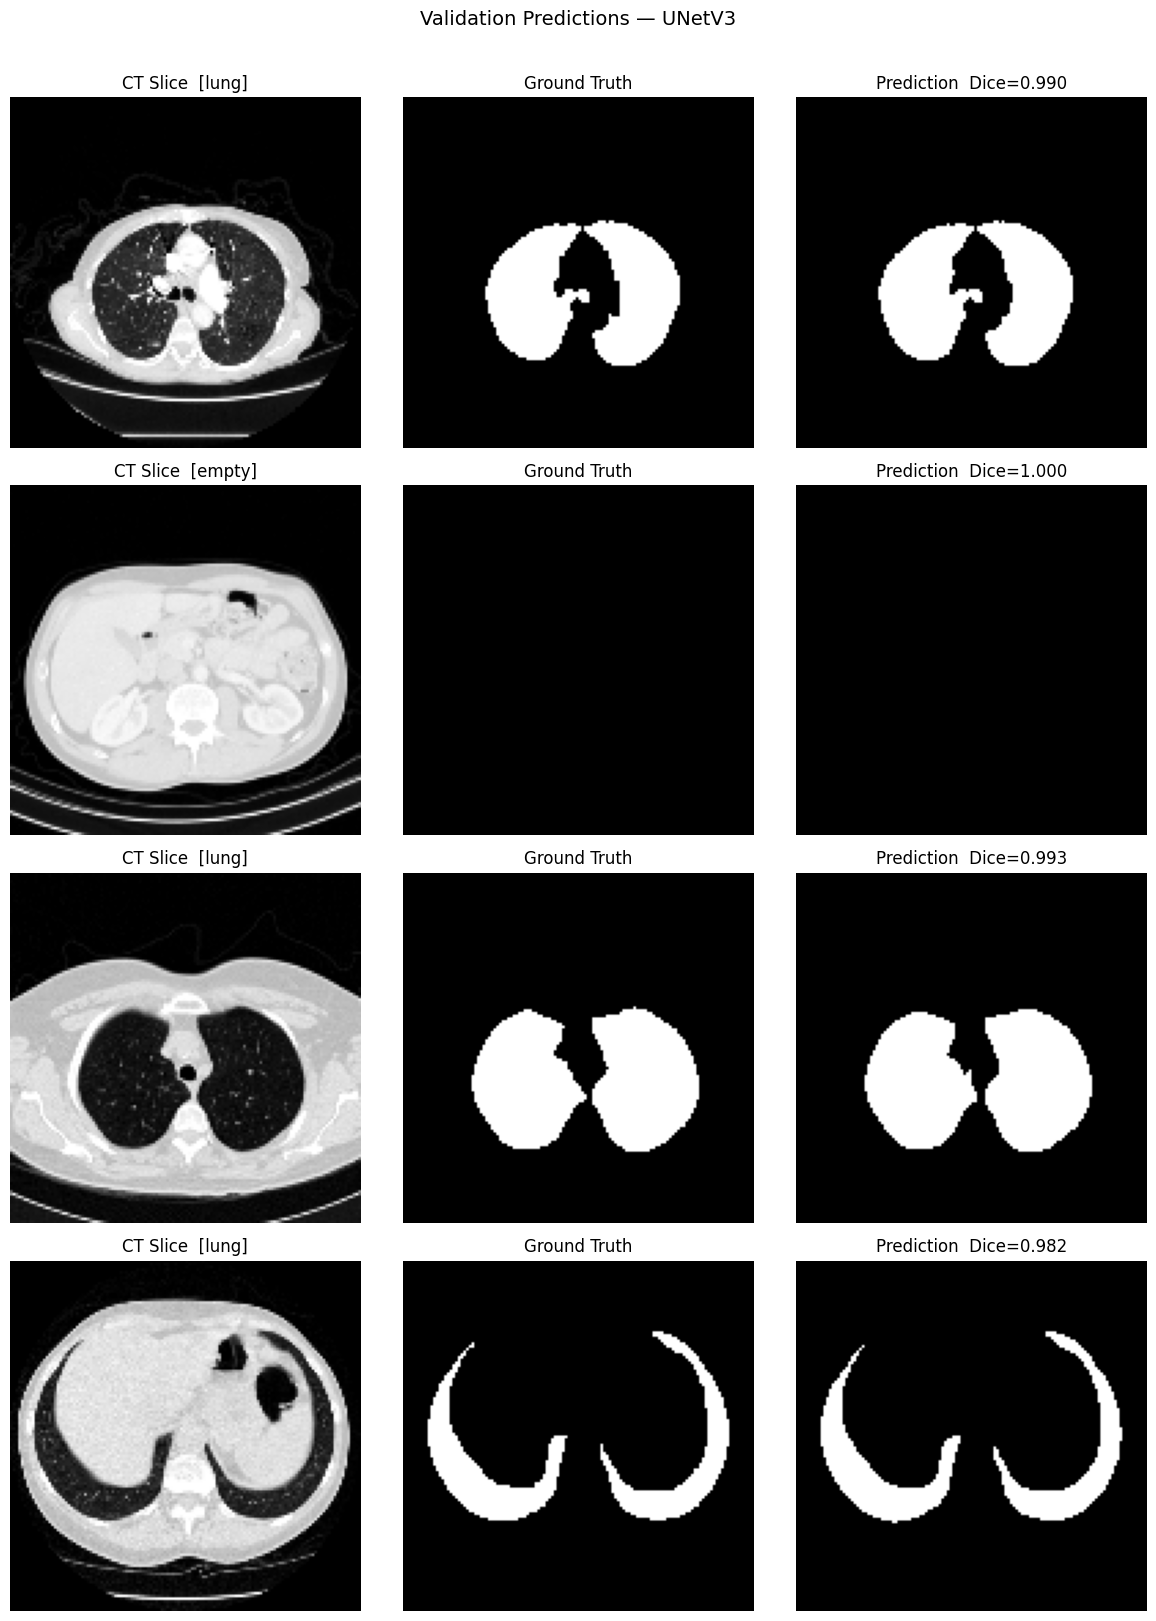

In [ ]:
# ============================================================
# CELL 10 — Prediction visualization
# Unchanged from v16 except 3-tuple unpack.
# ============================================================
assert "model"      in globals(), "Run Cell 7 first."
assert "val_loader" in globals(), "Run Cell 7 first."

N_SAMPLES = 4

model.eval()
dataset = val_loader.dataset
indices = random.sample(range(len(dataset)), N_SAMPLES)

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle("Validation Predictions — UNetV3", fontsize=14, y=1.01)

with torch.no_grad():
    for row, idx in enumerate(indices):
        sample = dataset[idx]
        if sample is None:
            print("Sample " + str(idx) + " returned None — skipping.", flush=True)
            continue
        img, msk, kind = sample
        logit = model(img.unsqueeze(0).to(DEVICE))
        pred  = (torch.sigmoid(logit) > 0.5).cpu().numpy()[0, 0]
        dice  = compute_metrics(logit, msk.unsqueeze(0).to(DEVICE))["dice"]

        axes[row, 0].imshow(img[0].numpy(), cmap="gray")
        axes[row, 0].set_title(f"CT Slice  [{kind}]"); axes[row, 0].axis("off")

        axes[row, 1].imshow(msk[0].numpy(), cmap="gray")
        axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")

        axes[row, 2].imshow(pred, cmap="gray")
        axes[row, 2].set_title(f"Prediction  Dice={dice:.3f}")
        axes[row, 2].axis("off")

plt.tight_layout()
vis_path = "/content/predictions_sample_v17.png"
plt.savefig(vis_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {vis_path}")
plt.show()